The main way to interact with the package is through the `Model` class. To initialize a model, you need to specify a cosmology, HMF, halo profile, redshift, and k grid. All of these have defaults. You may also provide the HOD model and its parameters, both of which are left unspecified by default. The HMF, halo profile, and HOD can all be modified after the model is instantiated. 

Right now, there are only the Tinker05 and Behroozi13 mass functions explicitly defined via the `MassFunction` class, but you can also define your own by defining a subclass with an _hmf and _bias function. The only halo profile currently built is the NFW profile, but once again, you can define your own as a subclass of `HaloProfile`. Lastly, the only predefined HOD is Zheng07, but you can write your own as a subclass of `HOD` with a centrals and a satellites method.

Once the model is defined, the power spectrum and correlation functions are simple to compute.

An important note is that at no point does the package ever use little-h units and distances are always co-moving.

Let's see an example.

In [2]:
import shoddy
import numpy as np
from matplotlib import pyplot as plt

In [5]:
# Let's build a model using only the defaults
mod = shoddy.Model()

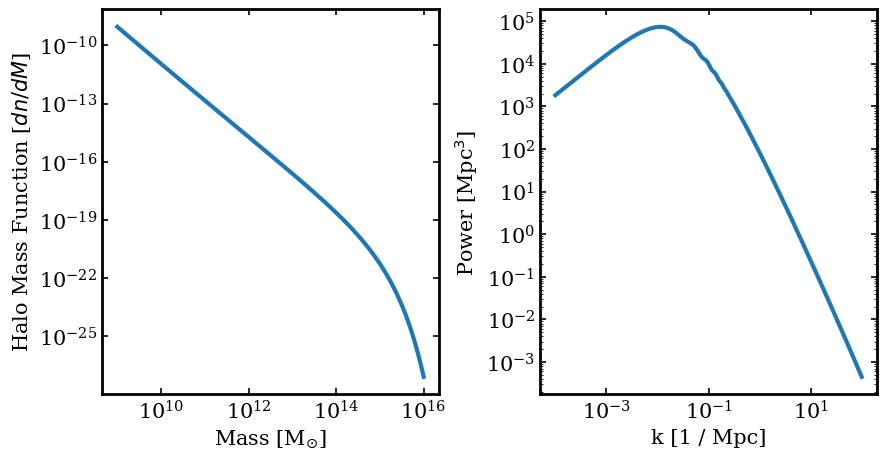

In [13]:
# We can plot the HMF or matter power spectrum for example

fig, ax = plt.subplots(1, 2, figsize=(10,5),
                       gridspec_kw={'wspace':0.3})

ax[0].loglog(mod.ms, mod.HMF.hmf(mod.ms))
ax[0].set_xlabel(r"Mass [M$_{\odot}$]")
ax[0].set_ylabel(r"Halo Mass Function [$dn / dM$]")

ax[1].loglog(mod.ks, mod.matter_power_spectrum(mod.ks))
ax[1].set_xlabel(r"k [1 / Mpc]")
ax[1].set_ylabel(r"Power [Mpc$^3$]")

plt.show()

In [14]:
# Now let's define an HOD so we can see galaxy power spectra and correlation functions.

hod_pars = {
    'M_min': 11.5,
    'M0': 12,
    'M1': 12.,
    'alpha': 1,
    'sig_logM': 0.2,
    'dc': 1
}

mod.set_hod('Zheng07', pars=hod_pars)

Galaxy number density: n = 9.12e-02 Mpc^-3
Galaxy bias: b = 1.60


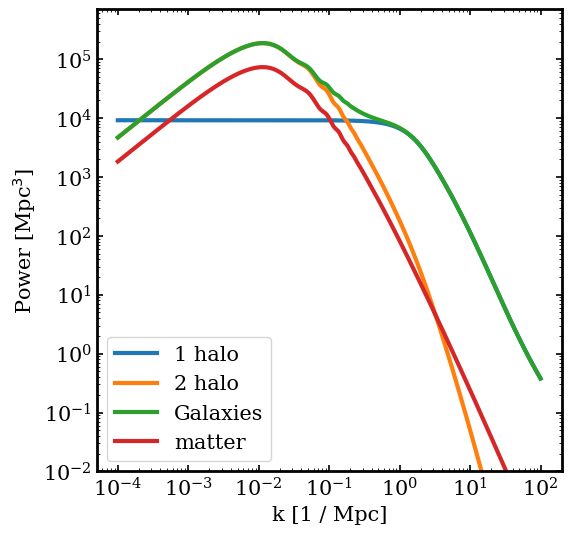

In [22]:
# Now we have access to numerous power spectra and summary statistics

print(f"Galaxy number density: n = {mod.n_gal():.2e} Mpc^-3")
print(f"Galaxy bias: b = {mod.galaxy_bias():.2f}")

fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.loglog(mod.ks, mod.Pk_1h(), label='1 halo')
ax.loglog(mod.ks, mod.Pk_2h(), label='2 halo')
ax.loglog(mod.ks, mod.P_gal(), label='Galaxies')
ax.loglog(mod.ks, mod.matter_power_spectrum(mod.ks), label='matter')

ax.set_xlabel(r"k [1 / Mpc]")
ax.set_ylabel(r"Power [Mpc$^3$]")

ax.set_ylim(bottom=1e-2)

ax.legend()

plt.show()

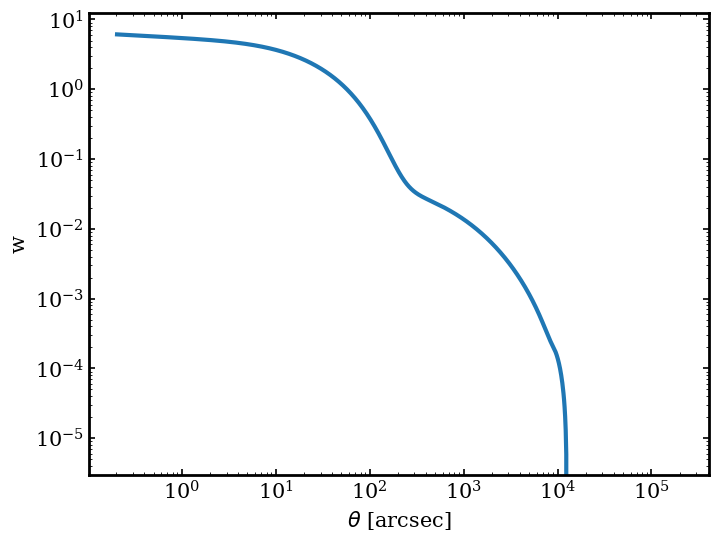

In [18]:
# To get angular clustering, we need to define a redshift window.
# Let's also try updating some of the parameters for the HOD

zgrid = np.linspace(0.5,1)
nzval = np.ones_like(zgrid) # Let's say the n(z) is flat

mod.update_hod_pars(M_min=10**11.0, M1=10**11.5, M0=10**11.5, alpha=1.1, sig_logM=0.3)
xi, theta = mod.cf_ang(z_arr=zgrid, nz=nzval)
plt.loglog(theta*3600, xi) # theta returns in degrees

plt.ylabel("w")
plt.xlabel(r"$\theta$ [arcsec]")

plt.show()